In [88]:
# Generation of the synthetic dataset

import numpy as np
import matplotlib.pyplot as plt

def generate_synthetic_dataset(n, d, seed=30):
    
    generator = np.random.default_rng(seed)
    
    w = generator.standard_normal(d)
    
    if d > 20:
        w[20:] = 0
    
    X_train = generator.standard_normal((n, d))
    X_test = generator.standard_normal((n, d))
    
    noise_train = generator.standard_normal(n)
    noise_test = generator.standard_normal(n)

    y_train = X_train @ w + noise_train
    y_test = X_test @ w + noise_test
    
    return X_train, y_train, X_test, y_test

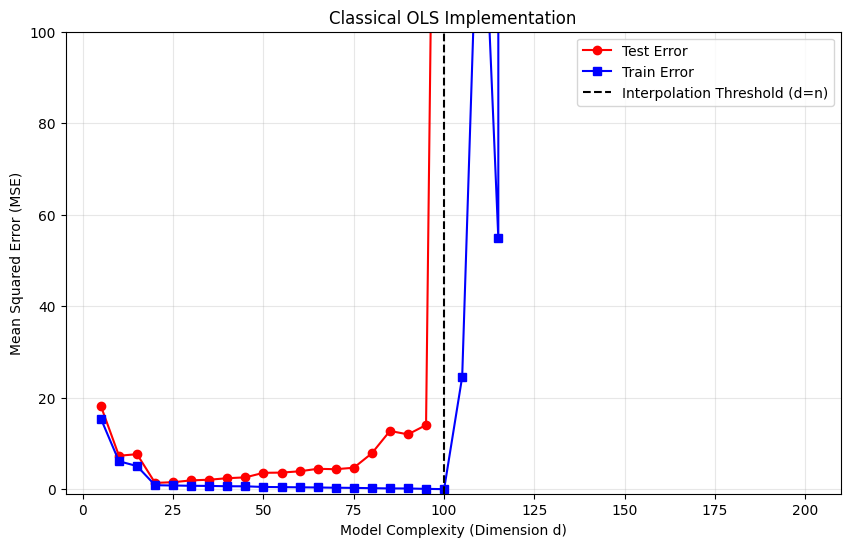

In [89]:
# Train of the model: least squares

def fit_ols_classical(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

def compute_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

n = 100
d_values = range(5, 205, 5)

X_tr_full, y_tr, X_te_full, y_te = generate_synthetic_dataset(n, 205, seed=30)

train_errors = []
test_errors = []

for d in d_values:
    X_tr = X_tr_full[:, :d]
    X_te = X_te_full[:, :d]
    
    #matrix_to_invert = X_tr.T @ X_tr
    #eigenvalues = np.linalg.eigvalsh(matrix_to_invert)
    #min_eig = np.min(np.abs(eigenvalues))
    
    w_hat = fit_ols_classical(X_tr, y_tr)
    
    #print(f"d = {d:3d} | Min Eigenvalue: {min_eig:.2e} | Max Weight: {np.max(np.abs(w_hat)):.2e}")    
    y_pred_tr = X_tr @ w_hat
    y_pred_te = X_te @ w_hat
    
    train_errors.append(compute_mse(y_tr, y_pred_tr))
    test_errors.append(compute_mse(y_te, y_pred_te))

plt.figure(figsize=(10, 6))
plt.plot(d_values, test_errors, label='Test Error', color='red', marker='o')
plt.plot(d_values, train_errors, label='Train Error', color='blue', marker='s')
plt.axvline(x=n, color='black', linestyle='--', label='Interpolation Threshold (d=n)')

plt.ylim(-1, 100)
plt.xlabel('Model Complexity (Dimension d)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Classical OLS Implementation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()